***Telecom Churn Analysis***

***Project Summary:  
This project analyzed customer churn data to uncover retention patterns. Using Python libraries (Pandas, Seaborn, Matplotlib), exploratory data analysis and visualizations were performed on demographic, tenure, and contract features. The study revealed that senior citizens and short‑tenure customers are more likely to churn, while long‑term contracts significantly reduce churn risk. These insights suggest that targeted retention strategies, such as loyalty programs and contract upgrades, can improve customer lifetime value.***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\ayush\\Downloads\\Customer Churn.csv")

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


***Replacing blanks with 0 as tenure is 0 and no total charges are recorded***

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [13]:
df["customerID"].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: customerID, Length: 7043, dtype: bool

In [14]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

In [15]:
df.head(30)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,no,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,no,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,no,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,no,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,no,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


***Converted 0 and 1 values of SeniorCitizen to yes/no to make it easier to understand***

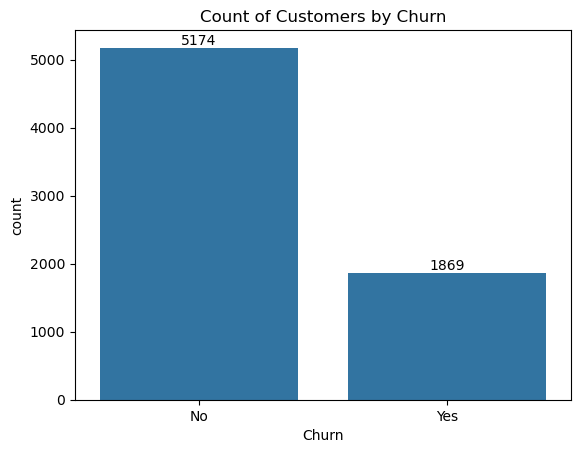

In [16]:
ax = sns.countplot(x = 'Churn', data = df)

ax. bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

***INSIGHTS: creates a count plot of customer churn, showing how many customers stayed versus how many left. It helps visualize the distribution of churn in the dataset, making the imbalance or trend easy to interpret."***

In [17]:
gb = df.groupby("Churn").agg({'Churn':"count"})

In [18]:
gb

,Churn
Churn,
No,5174
Yes,1869


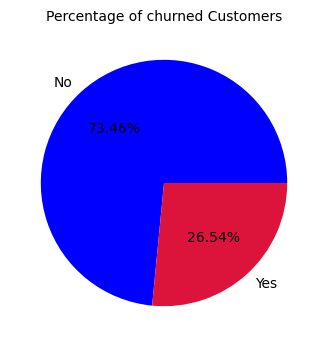

In [51]:
plt.figure(figsize = (5,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%", colors=["blue","crimson"])
plt.title("Percentage of churned Customers", fontsize = 10)
plt.show()

***INSIGHTS: a pie chart to show the percentage of customers who churned versus those who stayed. It helps visualize churn distribution in terms of proportions, making it easier to understand the overall churn rate."***

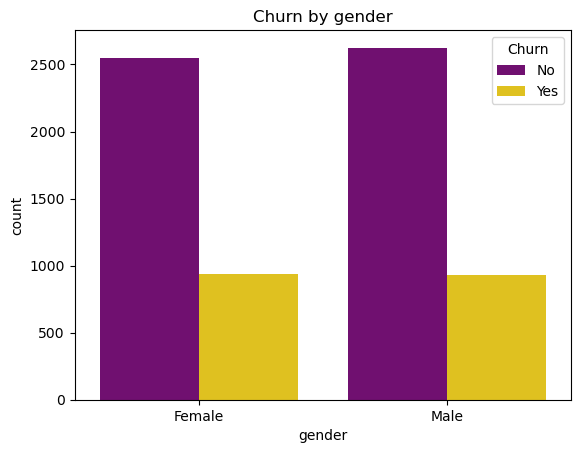

In [53]:
sns.countplot(x = "gender", data = df, hue = "Churn", palette=["purple","gold"])
plt.title("Churn by gender")
plt.show()

***INSIGHTS:plots the distribution of churn across genders, showing how many male and female customers stayed or left. It helps compare churn behavior between genders and identify if one group is more likely to churn."***

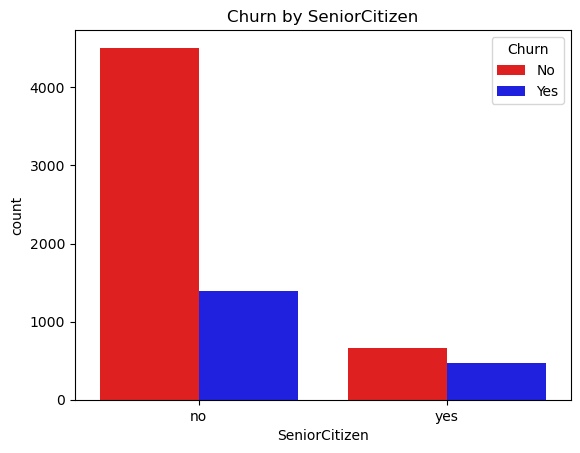

In [27]:
sns.countplot(x = "SeniorCitizen", data = df, hue = "Churn", palette=["red","blue"])
plt.title("Churn by SeniorCitizen")
plt.show()

***INSIGHTS: shows the churn distribution among senior citizens compared to non-senior customers. It helps analyze whether age group (senior vs. non-senior) has an impact on customer churn***

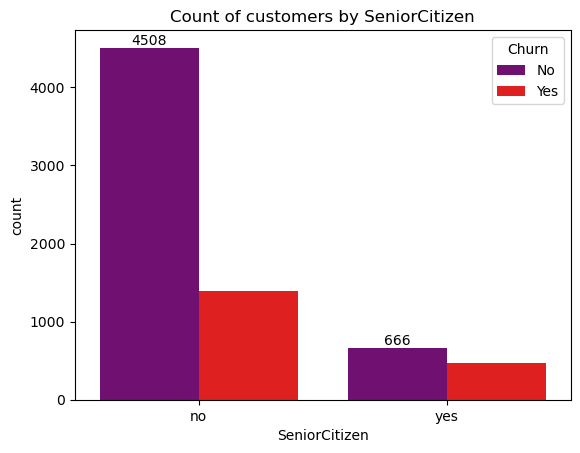

In [30]:
ax = sns.countplot(x = "SeniorCitizen", data = df,hue="Churn", palette=["purple","red"])
ax.bar_label(ax.containers[0])
plt.title("Count of customers by SeniorCitizen")
plt.show()

***INSIGHTS: shows the total number of senior citizens and non-senior customers in the dataset. Adding bar labels makes the counts clear, and the chart highlights the distribution of customers by age group.***

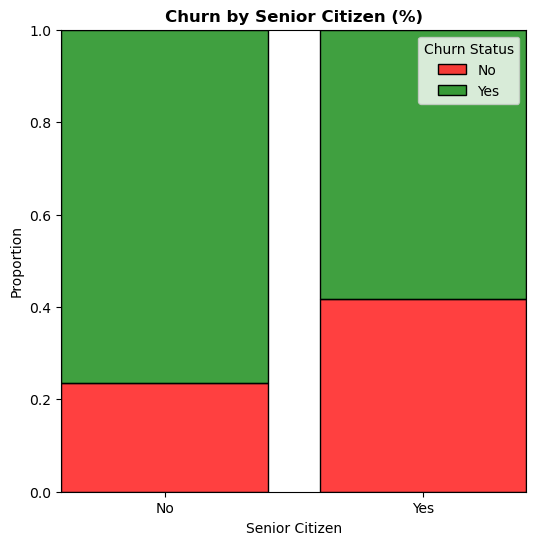

In [59]:
plt.figure(figsize=(6,6))
sns.histplot(
    data=df,
    x="SeniorCitizen", hue="Churn", multiple="fill", palette=["green","red"],shrink=0.8)

plt.title("Churn by Senior Citizen (%)", fontsize=12, fontweight="bold")
plt.xlabel("Senior Citizen")
plt.ylabel("Proportion")
plt.xticks([0,1], ["No","Yes"])
plt.legend(title="Churn Status", labels=["No", "Yes"], loc="upper right")
plt.show()


***INSIGHTS: creates a stacked bar chart showing churn percentages for senior citizens and non-senior customers. It helps compare churn behavior between the two groups, with percentage labels making the differences easy to interpret***

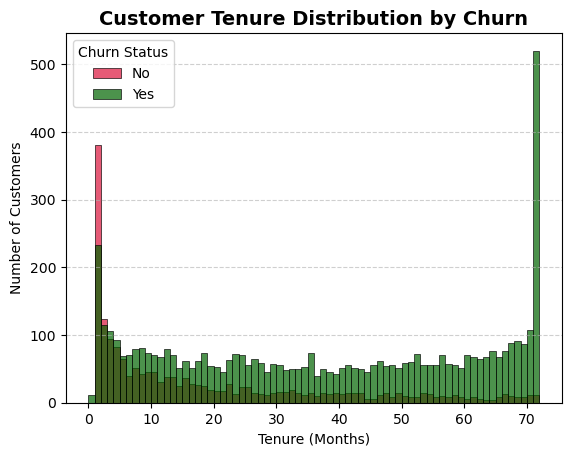

In [45]:
sns.histplot(x = "tenure", data = df, bins = 72, hue= "Churn", palette=["darkgreen","crimson"],alpha=0.7)
plt.title("Customer Tenure Distribution by Churn", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Churn Status", labels=["No", "Yes"], loc="upper left")
plt.show()

***INSIGHTS: plots a histogram of customer tenure with churn highlighted in different colors. It helps visualize how churn varies across different lengths of customer relationships, showing patterns in retention and attrition over time***

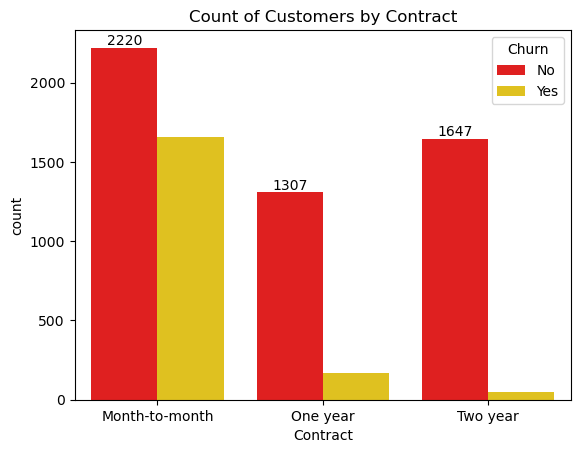

In [48]:
ax = sns.countplot(x = "Contract", data = df, hue="Churn", palette=["red","gold"])
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

***Insights: shows the total number of customers under each contract type (Month-to-month, One year, Two year). Adding bar labels makes the counts clear, and the chart highlights how customers are distributed across different contract categories***

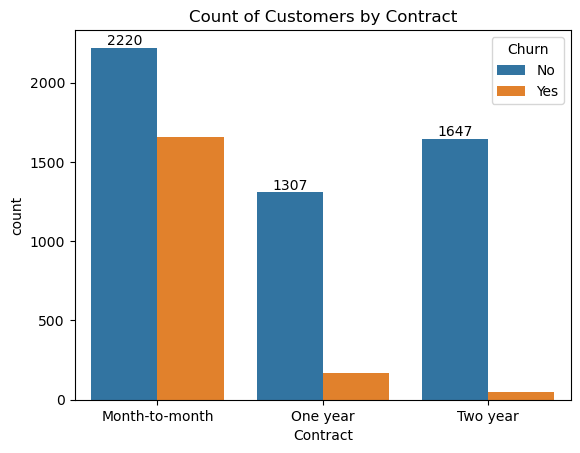

In [163]:
ax = sns.countplot(x = "Contract", data = df, hue= "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

***INSIGHTS:people who have month to month contracte are likely to churn then from those who have 1 or 2 years or contract***

In [174]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

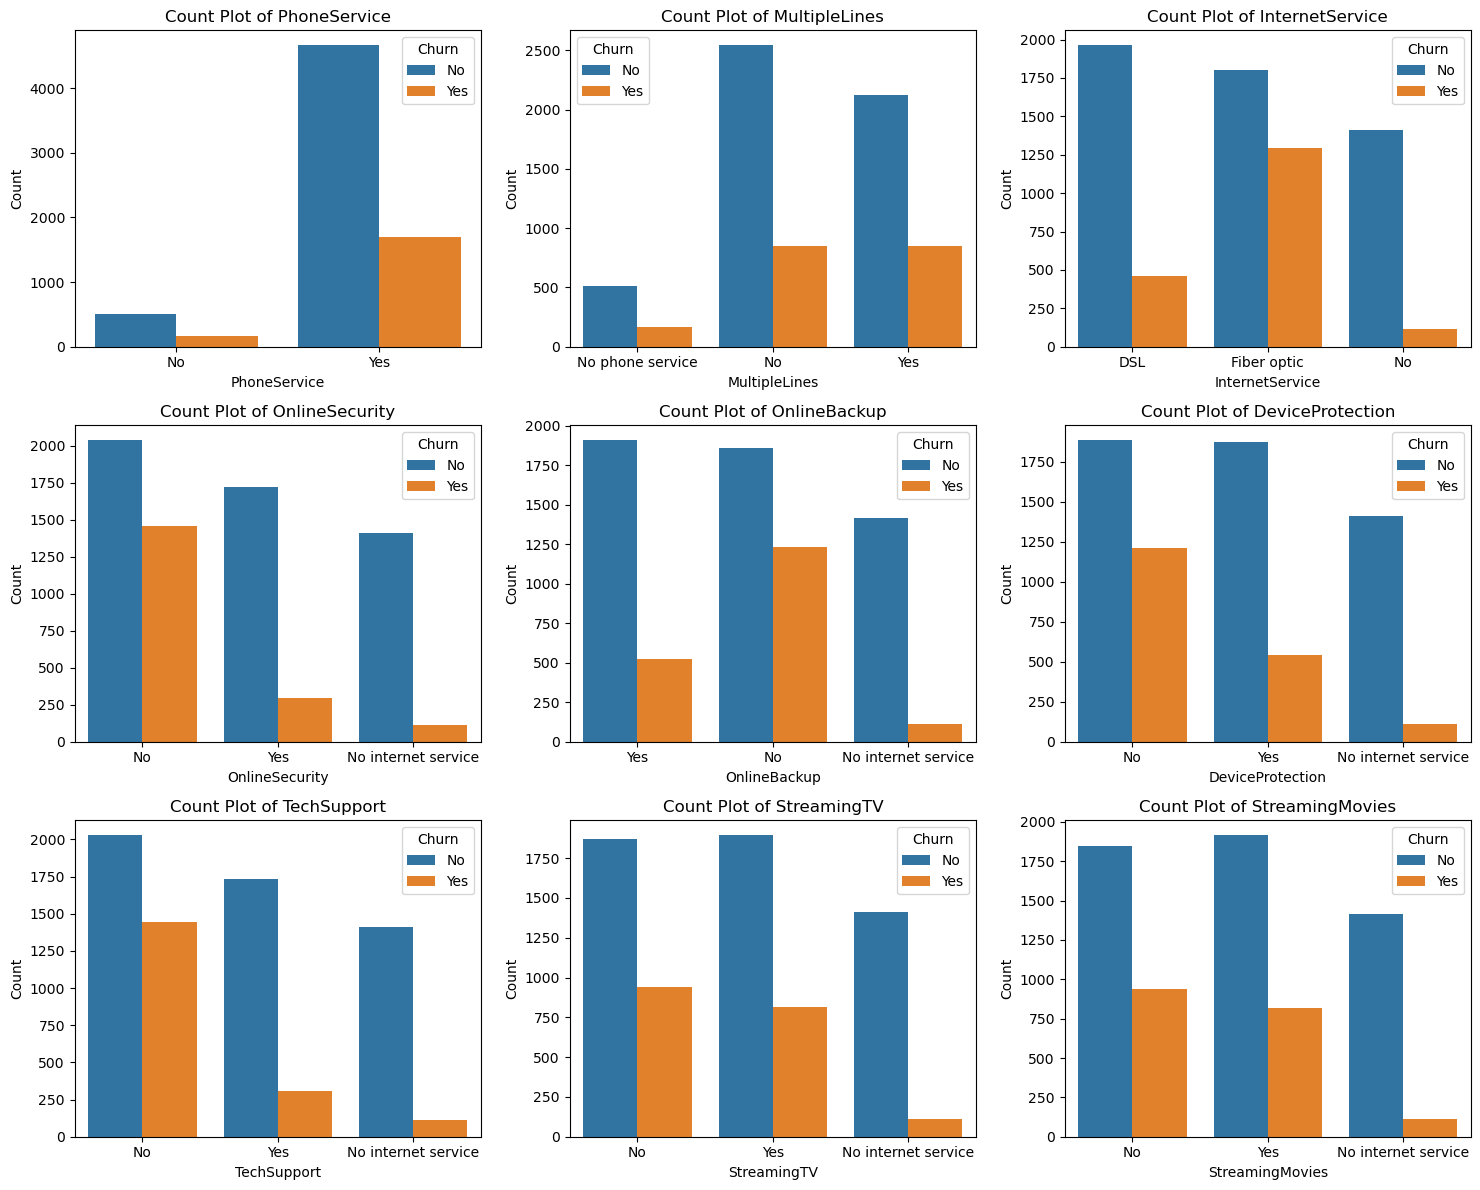

In [177]:
#list of columns for wich we want to create count plots 

columns = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies',]

#Number of columns for the subplot grid
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols #Calculate number of rows needed

#Creatwe Subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4)) 

#flatten the axes arrray for easy iteration 
axes = axes.flatten()

#Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

#Remove empty subplots

for j in range(i + 1, len(axes)):
    fig .deluxes(axes[j])

plt.tight_layout()
plt.show()

***INSIGHTS: generates multiple count plots for different service-related features (like PhoneService, InternetService, TechSupport, etc.) with churn highlighted. It helps visualize how each service is associated with customer churn, making it easier to spot patterns across multiple variables in one view***

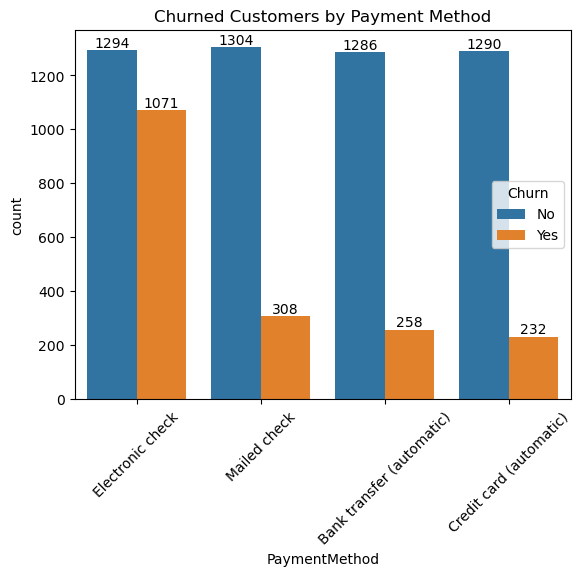

In [183]:
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

***INSIGHTS: creates a count plot of churn across different payment methods, showing how customers paying by electronic check, mailed check, credit card, or bank transfer differ in churn behavior. Bar labels and rotated x-axis make the chart easier to read and interpret.***

***In my churn analysis project, I started by cleaning the dataset—handling missing values, removing duplicates, and converting numeric fields like SeniorCitizen into categorical labels for better readability. Once the data was prepared, I performed exploratory analysis using Matplotlib and Seaborn. I built visualizations such as count plots, histograms, pie charts, and stacked bar charts to study churn patterns across demographics, tenure, contracts, services, and payment methods. These visual insights revealed which customer groups are more likely to churn, making the dataset ready for predictive modeling and helping businesses design targeted retention strategies."***


***Step 1: Data cleaning***

***Step 2: Visualization & analysis***

***Step 3: Insights & business value***